In [18]:
import numpy as np
from math import pow
import matplotlib.pyplot as plt
plt.style.use('bmh')
import pickle
from pathlib import Path
import os
from utils import *
from tqdm import tqdm

from models import DistanceCellModel, VectorCellModel, NestedModel
OUTPUT_DIR = 'simulation_outputs'


In [9]:
simulation_data_file = Path(OUTPUT_DIR) / f'sfd.pkl'

os.makedirs(simulation_data_file, exist_ok=True)

In [46]:



def navigation_simulation(model_name, arena_width = 50, n_trials=5, step_size = 0.01, convergence_threshold = 0.25, distortion=None, a=0, b=0, verbose=False):
    # step_size = 0.01, convergence_threshold = 0.025
    #Initialize corresponding model
    if model_name == 'dcm':
        model = DistanceCellModel(arena_width=arena_width, dc_res = 0.04)
    elif model_name == 'vcm':
        model = VectorCellModel(arena_width=arena_width)
    elif model_name == 'nm':
        model = NestedModel(arena_width=arena_width)
    else:
        raise ValueError("Invalid model name")

    x_histories = []
    y_histories = []

    for i in tqdm(range(n_trials), desc="Simulating trials"):
     
 #       print(f"Trial {i+1}/{n_trials}")
        # Sample a random starting position within the disk
        start_x, start_y = sample_disk_position(disk_radius = arena_width)
        goal_x, goal_y = [0, 0] #sample_disk_position(disk_radius = arena_width)
   #     print(f'ORIGINAL start_pos: ({start_x}, {start_y})')
   #     print(f'ORIGINAL goal_pos: ({goal_x}, {goal_y})')

        if distortion is not None:
         #   print('distortion!!!!!!')
            start_x, start_y = gc_distortion(start_x, start_y, distortion=distortion, a=a, b=b)
            goal_x, goal_y = gc_distortion(goal_x, goal_y, distortion=distortion, a=a, b=b)

            
            
        # Conduct simulations for ten steps
        x_history = [start_x]
        y_history = [start_y]
        converged = False
        step_count = 0
     #   print(f'start_pos: ({start_x}, {start_y})')
        while not converged:

            curr_pop_vec = model.forward(a=[start_x, start_y], b=[goal_x, goal_y])
     #       print('curr_pop_vec', curr_pop_vec)
            curr_pop_vec /= np.linalg.norm(curr_pop_vec) + 1e-10 # Normalize
     #       print('norm curr_pop_vec', curr_pop_vec)

            # Update position based on the population vector
            start_x = x_history[-1] + (curr_pop_vec[0] * step_size)
            start_y = y_history[-1] + (curr_pop_vec[1] * step_size)
            if verbose:
                print(f"Step {step_count}: Position ({start_x:.3f}, {start_y:.3f})")
    
            x_history.append(start_x)
            y_history.append(start_y)


            if distortion is not None:
                start_x, start_y = gc_distortion(x_history[-1], y_history[-1], distortion=distortion, a=a, b=b)
            # Check for convergence only after five steps
            if step_count > 5:
                #print('Check convergence')
                old_x = x_history[-5]
                old_y = y_history[-5]
                distance_moved = np.sqrt((start_x - old_x) ** 2 + (start_y - old_y) ** 2)
                if distance_moved < convergence_threshold or step_count > 2000:
                    converged = True
            step_count += 1
        x_histories.append(x_history)
        y_histories.append(y_history)
    return x_histories, y_histories

def run_load_simulation(model_name, arena_width, n_trials=400, step_size=0.1, distortion = None, a=None, b=None, save_plot=True):
    distortion_text = f'_{distortion}_a-{a}_b-{b}' if distortion is not None else ''
    simulation_data_file = Path(OUTPUT_DIR) / f'{model_name}_trials-{n_trials}{distortion_text}.pkl'
    # Run new simulation and save results
    if not os.path.exists(simulation_data_file):
        print('Running new simulation...')
        x_histories, y_histories = navigation_simulation(model_name, 
                                                         arena_width=arena_width, 
                                                         n_trials=n_trials,
                                                         step_size=step_size,
                                                         distortion=distortion, a=a, b=b,
                                                         verbose=False)
        if save_plot:
            with open(simulation_data_file, 'wb') as f:
                pickle.dump((x_histories, y_histories), f) 
                print(f'Saved simulation data to {simulation_data_file}')

    # Otherwise, load already simulated results
    else: 
        print(f'Loading simulation data from {simulation_data_file}')
        x_histories, y_histories = pickle.load(open(simulation_data_file, 'rb'))
    return [x_histories, y_histories]


Loading simulation data from simulation_outputs/nm_trials-400.pkl


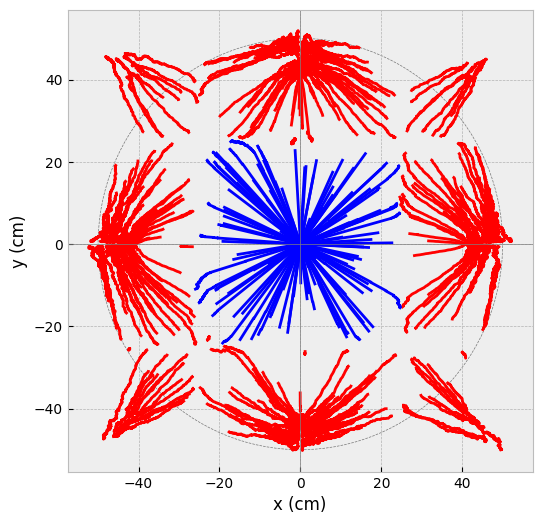

Successful trials: 125/400 (31.2%)
Loading simulation data from simulation_outputs/dcm_trials-400.pkl


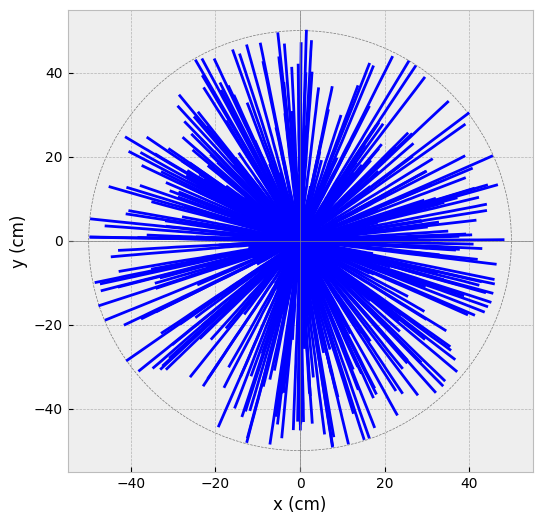

Successful trials: 400/400 (100.0%)
Loading simulation data from simulation_outputs/vcm_trials-400.pkl


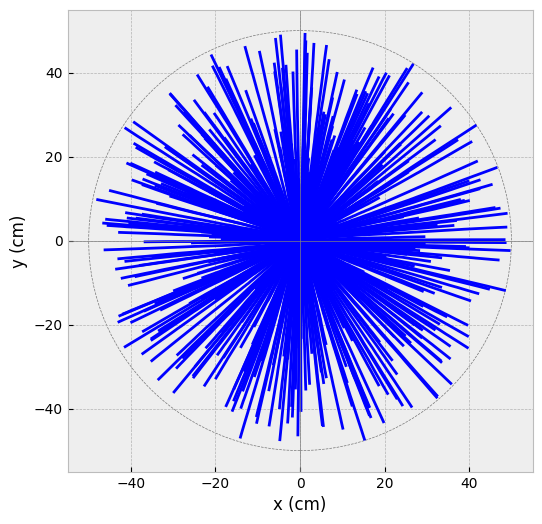

Successful trials: 400/400 (100.0%)


In [49]:
for model_name in ['nm', 'dcm', 'vcm']:
    x_histories, y_histories = run_load_simulation(model_name, 
                                                   arena_width = 50, 
                                                   n_trials=400, 
                                                   step_size=0.1)
    plot_trajectories(x_histories, y_histories)

Running new simulation...


Simulating trials: 100%|██████████| 400/400 [30:09<00:00,  4.52s/it] 


Saved simulation data to simulation_outputs/nm_trials-400_shear_a-0_b-0.3.pkl


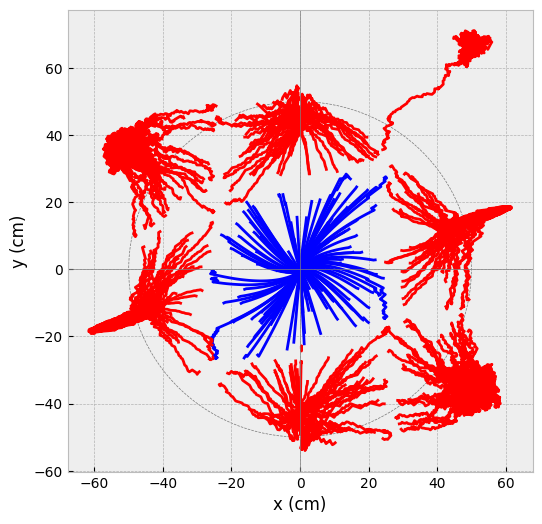

Successful trials: 116/400 (29.0%)


In [52]:
for model_name in ['nm']:
    x_histories, y_histories = run_load_simulation(model_name, 
                                                   arena_width = 50, 
                                                   n_trials=400, 
                                                   step_size=0.5,
                                                   distortion='shear', a=0, b=0.3)
    plot_trajectories(x_histories, y_histories)


In [3]:
def simulation(model_name, N=1000, title=None, arena_width = 50):

    #Initialize corresponding model
    if model_name == 'dcm':
        model = DistanceCellModel(arena_width=arena_width, dc_res = 0.04)
        print('model.xdc_positions', model.xdc_positions)
    elif model_name == 'vcm':
        model = VectorCellModel(arena_width=arena_width)
    elif model_name == 'nm':
        model = NestedModel(arena_width=arena_width)
    else:
        raise ValueError("Invalid model name")


    a_s = [(np.random.rand(N) * arena_width * 2) - arena_width for _ in range(2)]
    b_s = [np.zeros(N) for _ in range(2)]  # Target positions are all zeros [(np.random.rand(N) * arena_width * 2) - arena_width for _ in range(2)]
    b_hats = []
    for i in range(N):
        
        curr_pop_vec = model.forward(a=[a_s[0][i], a_s[1][i]], b=[b_s[0][i], b_s[1][i]])
        b_hats.append(curr_pop_vec)
    #    print(f'b_s[0][{i}]:', b_s[0][i])
        true_distance = [b_s[0][i] - a_s[0][i], b_s[1][i] - a_s[1][i] ]
    #    print(f'For trial {i+1}/{N}, true distance: ({true_distance[0]}, {true_distance[1]}), decoded b_hat: ({curr_pop_vec[0]}, {curr_pop_vec[1]})')
    b_hats = np.array(b_hats)

    # Plot two plots for x and y
    plt.subplots(1, 2, figsize=(12, 5))
    for i in range(2):
        plt.subplot(1, 2, i+1)
        plt.scatter((b_s[i] - a_s[i]) / 100, b_hats[:, i] / 100, color='black', s=1)
    #    plt.xlabel('True Translation Vector (m)')
    #    plt.ylabel('Decoded Translation Vector (m)')
    #    plt.ylim((-arena_width/100, arena_width/100))
        curr_axis = 'x' if i == 0 else 'y'
        plt.title(f'{curr_axis}-axis')
    plt.suptitle(title)
    plt.show()

model.xdc_positions [0.0000e+00 4.0000e-02 8.0000e-02 ... 4.9988e+02 4.9992e+02 4.9996e+02]


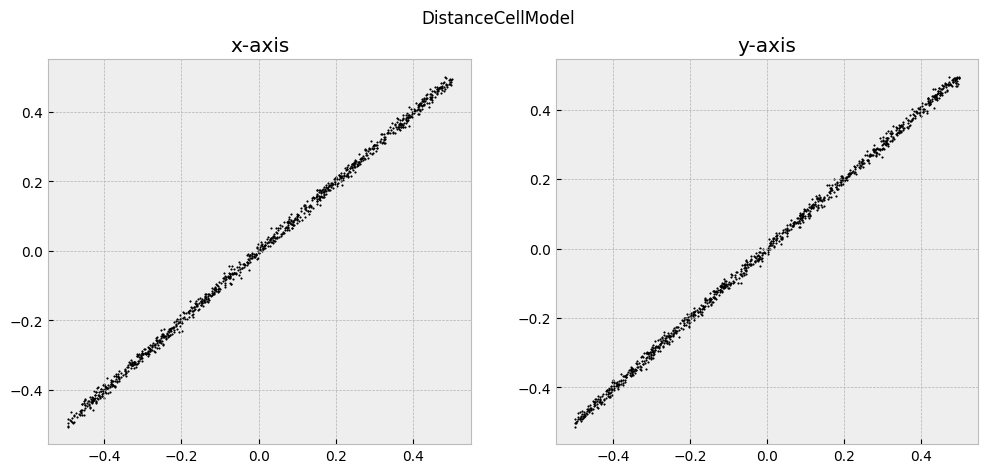

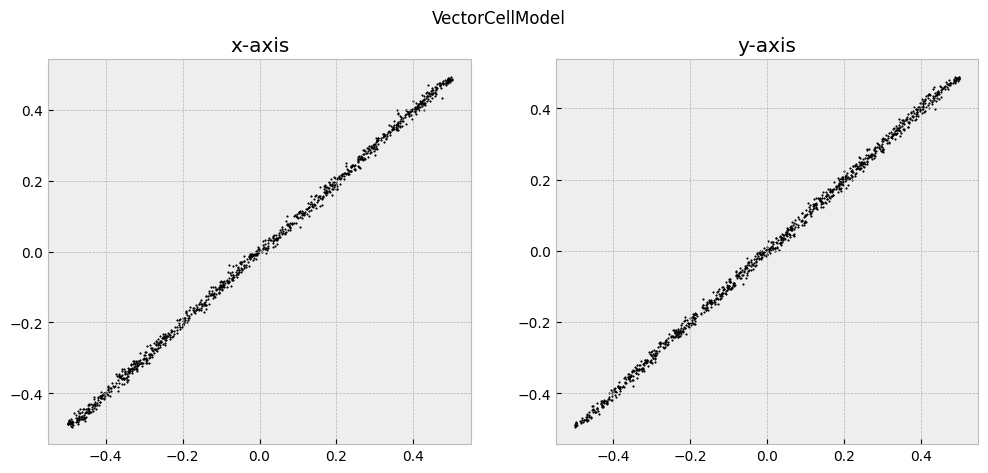

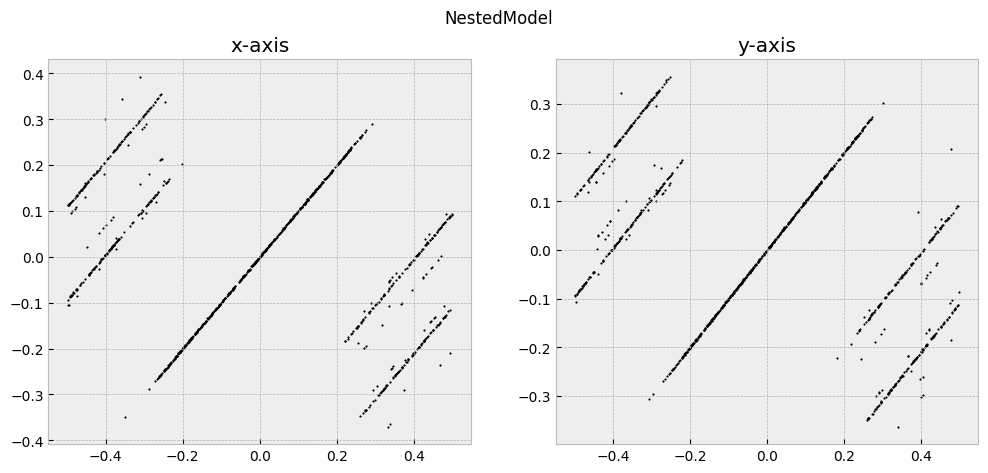

In [4]:
simulation('dcm', title='DistanceCellModel', arena_width = 50)
simulation('vcm', title='VectorCellModel', arena_width = 50)
simulation('nm', title='NestedModel', arena_width = 50)

### COMBINATORIAL (Bush et al., 2015)

In [5]:

  
dc_model = DistanceCellModel()
print(dc_model.forward(a=[250, 250], b=[258, 258]))
# Print different edge cases
#print(dc_model.forward(a=[0, 0], b=[500, 500]))
#print(dc_model.forward(a=[500, 500], b=[0, 0]))
#print(dc_model.forward(a=[250, 250], b=[250, 250]))
#print(dc_model.forward(a=[0, 500], b=[500, 0]))

[4.9996 9.9992]


In [6]:


vc_model = VectorCellModel2()
vec = vc_model.forward(a=[240, 250], b=[200, 270])
print('vec', vec)
'''
tr_vec = vc_model.forward(a=[250, 250], b=[260, 260])
print('Expected translation vector around [20, 20]. Model translation vector:', tr_vec)
print(vc_model.xvc_pos[:10])   # first 10 vc positions
print(vc_model.xvc_pos[-10:])  # last 10 vc positions
print(vc_model.Wpos.sum(axis=1)[:10])   # connections to first 10 VCs
print(vc_model.Wpos.sum(axis=1)[-10:])  # connections to last 10 VCs
'''


NameError: name 'VectorCellModel2' is not defined

### OLD CODE

In [ ]:
# Original init method with all parameters

def __init__(self, M = 10, s_M = 25, alpha = 1.4, m = 20, r_max = 30, N_dc = 12500, dc_res = 4, time_w = 0.1):
        super().__init__(M, s_M, alpha, m, r_max, time_w)
        self.N_dc = N_dc    # Number of distance cells
        self.dc_res = dc_res       # Distance cell spatial resolution (cm)
        self.alpha = alpha  # Common factor (for geometric progression)
        self.m = m          # Number of equally distributes spatial phases
        self.r_max = r_max  # Maximum GC firing rate (Hz)
        self.N_dc = N_dc    # Number of distance cells
        self.dc_res = dc_res       # Distance cell spatial resolution (cm)
        self.poiss_time_w = time_w # Time window in Poisson process (secs)

        # Initialize networks parameters
        self.scales = self._create_scales()
        self.phases = self._create_phases()
        self.xdc_positions = self._create_distance_cells()
        self.W_dcs = self._compute_weight_matrix()  
        self.W_pos_readout = self.xdc_positions / self.xdc_positions.max()  # Increases linearly with displacement along axis
        self.W_neg_readout = self.W_pos_readout.copy()[::-1]              # Decreases linearly (to encode opposite direction)

In [ ]:

vc_model = VectorCellModel()
tr_vec = vc_model.forward(a=[250, 250], b=[260, 260])
print('Expected translation vector around [20, 20]. Model translation vector:', tr_vec)
print(vc_model.xvc_pos[:10])   # first 10 vc positions
print(vc_model.xvc_pos[-10:])  # last 10 vc positions
print(vc_model.Wpos.sum(axis=1)[:10])   # connections to first 10 VCs
print(vc_model.Wpos.sum(axis=1)[-10:])  # connections to last 10 VCs


In [ ]:

# From nested model
    def eq_2(self, spikes, lambda_i, lambda_i_idx):
        # Here lambda_i = lambda_0
        curr_sum = np.sum([spikes[lambda_i_idx][j] * self._phasor(c_j, lambda_i) for j,c_j in enumerate(self.phases[lambda_i_idx])])
        return (lambda_i / (2 * np.pi)) * np.angle(curr_sum)


    def eq_3(self, spikes, lambda_i, lambda_i_idx, curr_x_est, eta_tilde):
        curr_sum = np.sum([spikes[lambda_i_idx][j] * self._phasor(c_j, lambda_i) for j,c_j in enumerate(self.phases[lambda_i_idx])])
        curr_x_est += eta_tilde * (lambda_i / (2 * np.pi)) * np.angle(self._phasor(-curr_x_est, lambda_i) * curr_sum)
        return curr_x_est

    def population_vec_1d_old(self, gc_acts):
        ''' Computes population vector using nested approach according to eqs. 2 & 3 in Stemmler. et al (2015)
        '''
        lambda_i_idx = 0
        lambda_i = self.scales[lambda_i_idx]
        curr_x_est = self.eq_2(gc_acts, lambda_i, lambda_i_idx)
        print('---curr_x_est',curr_x_est)
        cum_precision = self.m * lambda_i**-2  
        for lambda_i_idx in np.arange(1, len(self.scales)):
            lambda_i = self.scales[lambda_i_idx]
            precision_i = self.m * lambda_i**-2
            eta_tilde = precision_i / (cum_precision + precision_i)
            curr_x_est = self.eq_3(gc_acts, lambda_i, lambda_i_idx, curr_x_est, eta_tilde)
            cum_precision += precision_i
        return curr_x_est

In [ ]:
lambda_j = 50
omega = (2 * np.pi) / (np.sin(np.pi / 3) * lambda_j)

def k_vec(l):
    phi_l = - (np.pi / 6) + (l * np.pi / 3)
    return np.array([np.cos(phi_l), np.sin(phi_l)])

def f(x_vec, l=1):
    return np.cos((omega * k_vec(l)) @ x_vec)

f([0,1])

def _gc_rate_2D(self, a, lambda_j, c_j, kappa=1):
    ''' Calculates GC firing rate based on von Mises function for 2D case.
        a=2D current position
        lambda_j=spatial period
        c_j=2D spatial phases
        kappa=relative tuning width
        '''
    a = np.array(a)
    c_j = np.array(c_j)
    omega = (2 * np.pi) / (np.sin(np.pi / 3) * lambda_j)
    return self.r_max * np.exp((kappa/3) * np.sum([np.cos((omega * k_vec(l)) @ (a - c_j)) - 1 for l in [1,2,3]]))

def population_vector_2D(self, a):
    ''' Computes population vector using nested approach according to eq. 6 in Stemmler. et al (2015)
    '''
    # 1. Get spikes for current location
    spikes = self._gc_spikes(a)
    print(spikes)
    
